In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
df_meta = pd.read_csv("/work/data/metadata/metadata_final.csv")

# normalizza nomi colonne (evita errori per maiuscole/spazi)
df_meta.columns = [c.strip().lower() for c in df_meta.columns]

df_meta.head()

,rank,box_office_year,imdb_id,title,release_year,distributor,genre,domestic_box_office_gross,tickets_sold
0,1,1980,tt0080684,Star Wars Ep. V: The Empire Strikes Back,1980,20th Century Fox,Adventure,181353855,67417790.0
1,2,1980,tt0081562,Stir Crazy,1980,Columbia,Black Comedy,101300000,37657992.0
2,3,1980,tt0079417,Kramer vs. Kramer,1979,NaN,Drama,98982763,36796566.0
3,4,1980,tt0080339,Airplane!,1980,Paramount Pictures,Comedy,83453539,31023620.0
4,5,1980,tt0080377,Any Which Way You Can,1980,Warner Bros.,Comedy,70687344,26277823.0


### Verifica della struttura e dei valori mancanti

Si procede a un controllo preliminare della forma del dataset, della tipologia delle variabili e dell’eventuale presenza di valori mancanti.

Questa analisi consente di identificare criticità strutturali (es. colonne incomplete o variabili non numeriche) che potrebbero influenzare la modellizzazione successiva.

In [3]:
print("Shape:", df_meta.shape)
display(df_meta.info())

missing = df_meta.isna().mean().sort_values(ascending=False)
missing[missing > 0].head(20)

Shape: (4100, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rank                       4100 non-null   int64  
 1   box_office_year            4100 non-null   int64  
 2   imdb_id                    4100 non-null   object 
 3   title                      4100 non-null   object 
 4   release_year               4100 non-null   int64  
 5   distributor                4045 non-null   object 
 6   genre                      4084 non-null   object 
 7   domestic_box_office_gross  4100 non-null   int64  
 8   tickets_sold               4097 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 288.4+ KB


None

distributor     0.013415
genre           0.003902
tickets_sold    0.000732
dtype: float64

### Standardizzazione delle variabili numeriche e costruzione della decade

Le variabili temporali ed economiche vengono convertite in formato numerico per consentire analisi quantitative coerenti.

La costruzione della variabile `decade`, derivata da `release_year`, permette di aggregare i film in blocchi temporali omogenei, condizione necessaria per l’analisi diacronica delle trasformazioni tematiche.

In [4]:
# cast numerici
df_meta["box_office_year"] = pd.to_numeric(df_meta["box_office_year"], errors="coerce")
df_meta["release_year"] = pd.to_numeric(df_meta["release_year"], errors="coerce")

df_meta["domestic_box_office_gross"] = pd.to_numeric(df_meta["domestic_box_office_gross"], errors="coerce")
df_meta["tickets_sold"] = pd.to_numeric(df_meta["tickets_sold"], errors="coerce")
df_meta["rank"] = pd.to_numeric(df_meta["rank"], errors="coerce")

# filtro periodo della tesi (box office)
df_meta = df_meta[df_meta["box_office_year"].between(1980, 2020)].copy()

# decade basata su box office year
df_meta["decade"] = (df_meta["box_office_year"] // 10) * 10

df_meta[["title","box_office_year","decade","domestic_box_office_gross","tickets_sold"]].head()


,title,box_office_year,decade,domestic_box_office_gross,tickets_sold
0,Star Wars Ep. V: The Empire Strikes Back,1980,1980,181353855,67417790.0
1,Stir Crazy,1980,1980,101300000,37657992.0
2,Kramer vs. Kramer,1980,1980,98982763,36796566.0
3,Airplane!,1980,1980,83453539,31023620.0
4,Any Which Way You Can,1980,1980,70687344,26277823.0


### Distribuzione dei film per decade

Questo grafico verifica l’equilibrio temporale del corpus.  
Una distribuzione relativamente omogenea tra le decadi garantisce che eventuali differenze tematiche non siano il risultato di squilibri campionari.

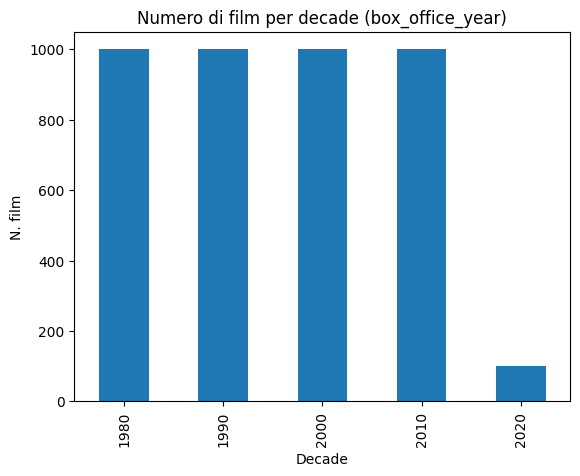

In [5]:
ax = df_meta["decade"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Numero di film per decade (box_office_year)")
ax.set_xlabel("Decade")
ax.set_ylabel("N. film")
plt.show()


Il corpus risulta fortemente concentrato nelle decadi 1980–2010, con una distribuzione relativamente stabile del numero di film per periodo.  
La presenza marginale di decadi precedenti è residuale e non incide sull’equilibrio complessivo dell’analisi diacronica.

Il dataset può quindi essere considerato temporalmente coerente rispetto all’obiettivo di analizzare il cinema mainstream dal 1980 in avanti.

### Distribuzione annuale dei film

L’analisi per anno consente di osservare eventuali concentrazioni o discontinuità temporali all’interno delle singole decadi, fornendo un controllo più fine sulla rappresentatività del corpus.

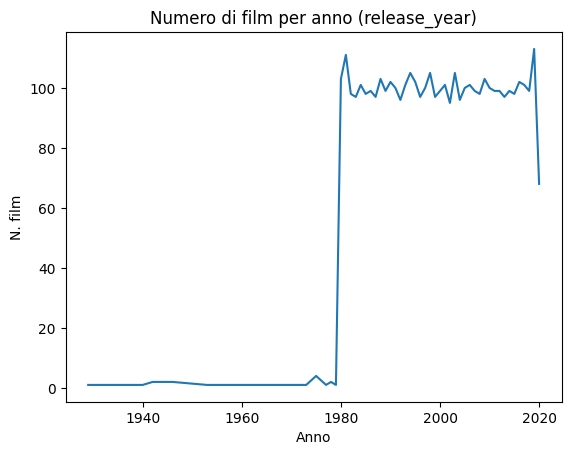

In [6]:
ax = df_meta["release_year"].value_counts().sort_index().plot(kind="line")
ax.set_title("Numero di film per anno (release_year)")
ax.set_xlabel("Anno")
ax.set_ylabel("N. film")
plt.show()

### Distribuzione dei generi cinematografici

L’analisi dei generi permette di valutare la varietà narrativa del corpus.  
Una forte concentrazione su un singolo genere potrebbe influenzare la distribuzione tematica, introducendo potenziali bias interpretativi.

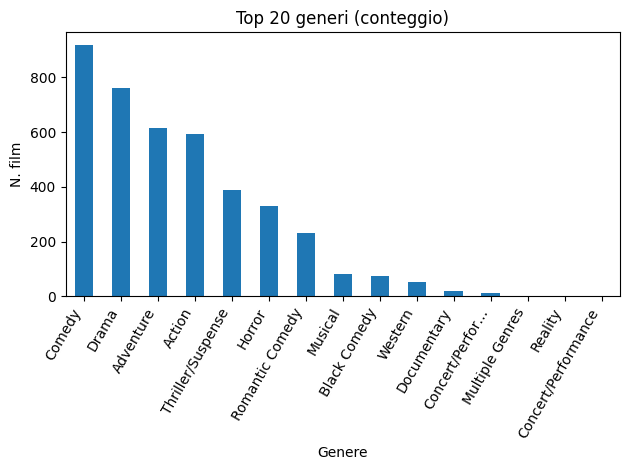

In [7]:
top_genres = df_meta["genre"].value_counts().head(20)
ax = top_genres.plot(kind="bar")
ax.set_title("Top 20 generi (conteggio)")
ax.set_xlabel("Genere")
ax.set_ylabel("N. film")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


Il corpus è dominato da generi mainstream come Comedy, Drama, Adventure e Action.  
La concentrazione su generi ad alta circolazione commerciale riflette la natura industriale del campione e conferma l’orientamento verso il cinema ad ampia distribuzione.

La varietà comunque è presente e dovrebbe permettere di ridurre il rischio di un’eccessiva omogeneità narrativa.

### Distribuzione dei principali distributori

L’analisi dei distributor offre un’indicazione della concentrazione industriale del corpus.  
Questa dimensione è rilevante poiché le logiche produttive possono influenzare la selezione e la ricorrenza dei temi narrativi.

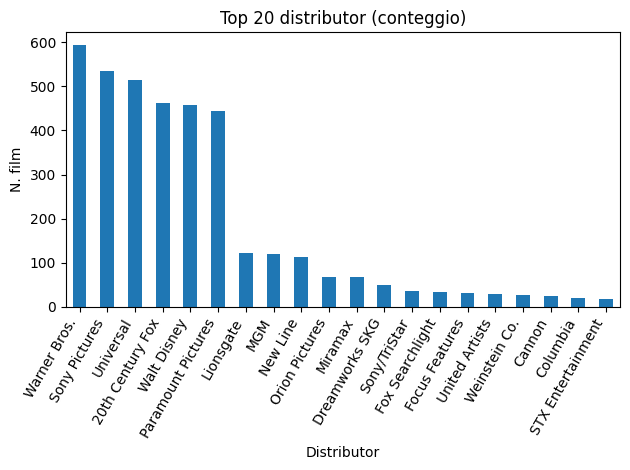

In [8]:
top_dist = df_meta["distributor"].value_counts().head(20)

ax = top_dist.plot(kind="bar")
ax.set_title("Top 20 distributor (conteggio)")
ax.set_xlabel("Distributor")
ax.set_ylabel("N. film")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

La distribuzione evidenzia una forte concentrazione nei principali studios statunitensi (Warner Bros., Universal, 20th Century Fox, Paramount, ecc.).

Questo dato conferma la natura industriale e mainstream del corpus, elemento rilevante poiché le logiche produttive possono influenzare la selezione e la reiterazione di specifici pattern tematici.

### Distribuzione degli incassi domestici (valori grezzi)

L’analisi della distribuzione degli incassi permette di individuare asimmetrie e outlier.  
I dati economici cinematografici presentano tipicamente una distribuzione fortemente asimmetrica, con pochi film ad altissimo incasso.

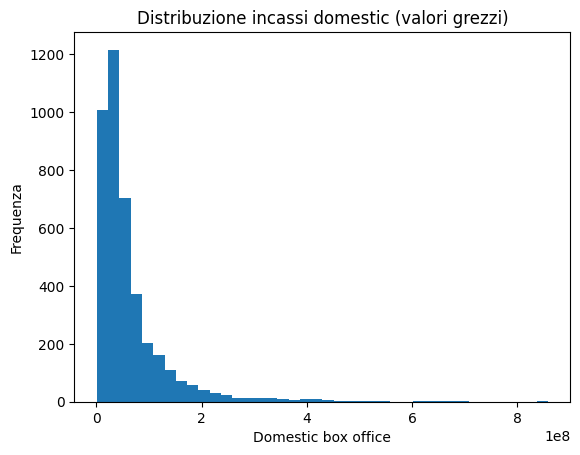

In [9]:
x = df_meta["domestic_box_office_gross"].dropna()

plt.hist(x, bins=40)
plt.title("Distribuzione incassi domestic (valori grezzi)")
plt.xlabel("Domestic box office")
plt.ylabel("Frequenza")
plt.show()

Il grafico appare fortemente asimmetrica, con una lunga coda destra: pochi film registrano incassi estremamente elevati, mentre la maggioranza si colloca in fasce medio-basse.

Passiamo ad una trasformazione logaritmica per analisi comparative più leggibili.

### Distribuzione degli incassi domestici (scala logaritmica)

La trasformazione logaritmica consente di rendere leggibile una distribuzione fortemente sbilanciata, facilitando l’identificazione di pattern e cluster economici all’interno del corpus.

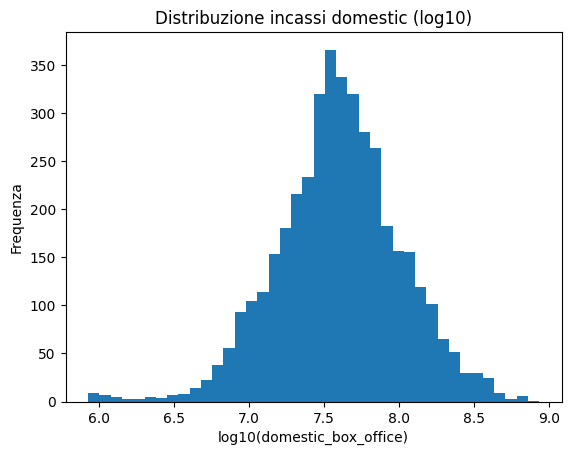

In [10]:
x = df_meta["domestic_box_office_gross"].dropna()
x = x[x > 0]

plt.hist(np.log10(x), bins=40)
plt.title("Distribuzione incassi domestic (log10)")
plt.xlabel("log10(domestic_box_office)")
plt.ylabel("Frequenza")
plt.show()


La trasformazione logaritmica riduce l’effetto dei valori estremi, rendendo la distribuzione più compatta e interpretabile.
Si osserva una concentrazione attorno a una fascia centrale, che rappresenta il segmento più consistente del mercato.
Questa rappresentazione permette di distinguere con maggiore chiarezza tra blockbuster e produzioni di fascia intermedia.

### Incasso medio per decade

Il confronto tra le medie decennali permette di osservare eventuali trend economici nel lungo periodo.

Questa variabile potrà essere successivamente messa in relazione con la salienza tematica per esplorare il rapporto tra configurazioni narrative e successo commerciale.

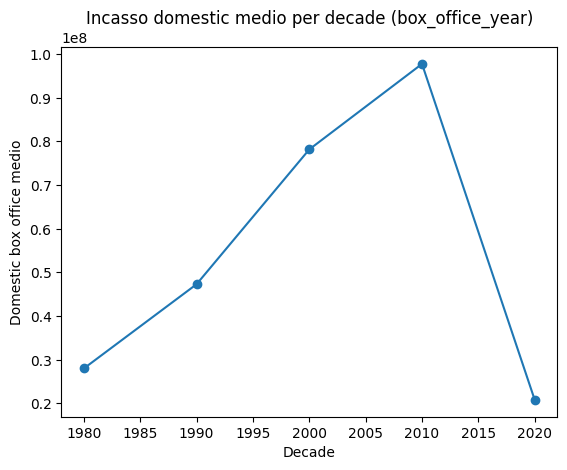

In [11]:
mean_by_decade = df_meta.groupby("decade")["domestic_box_office_gross"].mean()

ax = mean_by_decade.plot(kind="line", marker="o")
ax.set_title("Incasso domestic medio per decade (box_office_year)")
ax.set_xlabel("Decade")
ax.set_ylabel("Domestic box office medio")
plt.show()


Si osserva una crescita progressiva degli incassi medi tra anni Ottanta e Duemila, seguita da una flessione nell’ultima decade.

Il trend riflette dinamiche strutturali dell’industria cinematografica (inflazione, espansione globale, trasformazioni del mercato), più che variazioni puramente tematiche.

### Analisi dei biglietti venduti + trend per decade

L’inclusione della variabile `tickets_sold` consente di distinguere tra successo monetario e successo in termini di pubblico effettivo, offrendo una prospettiva più articolata sulla ricezione dei film.

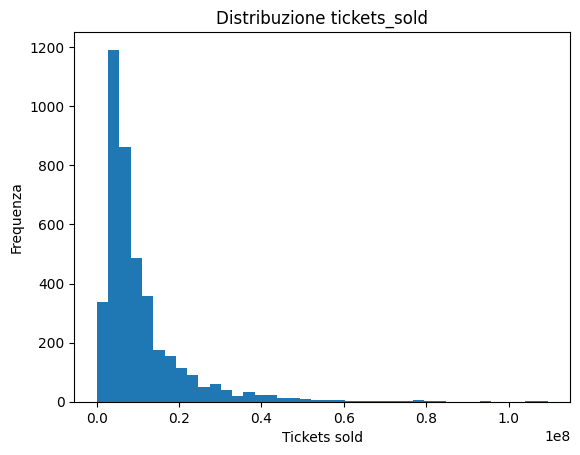

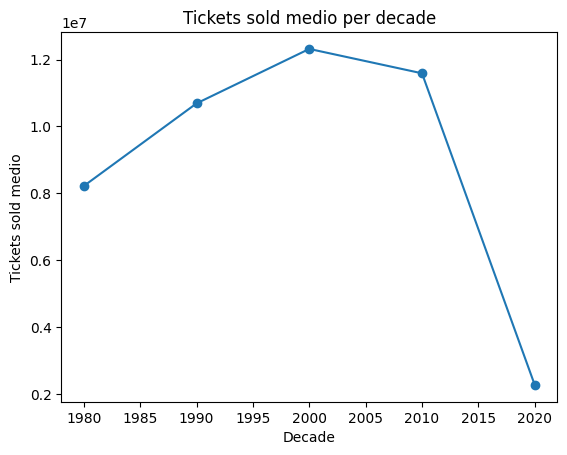

In [12]:
x = df_meta["tickets_sold"].dropna()

plt.hist(x, bins=40)
plt.title("Distribuzione tickets_sold")
plt.xlabel("Tickets sold")
plt.ylabel("Frequenza")
plt.show()

mean_tickets = df_meta.groupby("decade")["tickets_sold"].mean()
ax = mean_tickets.plot(kind="line", marker="o")
ax.set_title("Tickets sold medio per decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Tickets sold medio")
plt.show()

L’andamento mostra variazioni più marcate rispetto agli incassi medi, suggerendo che la relazione tra pubblico e performance economica non sia completamente lineare nel lungo periodo.
Le differenze possono essere attribuite a trasformazioni nelle modalità di fruizione cinematografica e nelle politiche di prezzo.

### Matrice di correlazione tra variabili numeriche

La matrice di correlazione consente di individuare relazioni preliminari tra variabili temporali ed economiche.

Questa fase non ha valore interpretativo definitivo, ma permette di identificare eventuali relazioni strutturali rilevanti per l’analisi successiva.

In [13]:
num_cols = ["rank","box_office_year","release_year","domestic_box_office_gross","tickets_sold"]
corr = df_meta[num_cols].corr()

corr

,rank,box_office_year,release_year,domestic_box_office_gross,tickets_sold
rank,1.000000e+00,-3.486643e-15,-0.005665,-0.639846,-0.735699
box_office_year,-3.486643e-15,1.000000e+00,0.974791,0.348652,0.088323
release_year,-5.665090e-03,9.747905e-01,1.000000,0.351537,0.096213
domestic_box_office_gross,-6.398464e-01,3.486519e-01,0.351537,1.000000,0.908647
tickets_sold,-7.356987e-01,8.832307e-02,0.096213,0.908647,1.000000


grafico heatmap

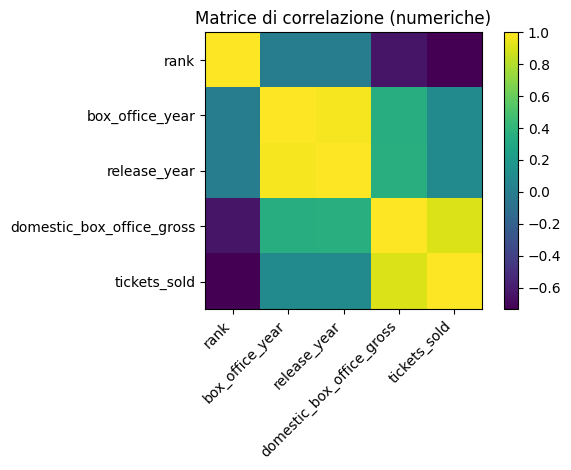

In [14]:
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.title("Matrice di correlazione (numeriche)")
plt.tight_layout()
plt.show()

La forte correlazione positiva tra `domestic_box_office` e `tickets_sold` indica che le due variabili descrivono lo stesso fenomeno da prospettive diverse: una monetaria (incasso totale) e una quantitativa (numero di spettatori). All’aumentare dei biglietti venduti aumenta proporzionalmente anche l’incasso, confermando la coerenza interna del dataset.

La correlazione negativa tra `rank` e le variabili economiche è coerente con la logica della classifica: un valore di rank più elevato corrisponde a una posizione peggiore e quindi, in media, a incassi inferiori. Non si tratta di una relazione causale, ma di una struttura intrinseca al sistema di ordinamento.

Le correlazioni positive tra le variabili temporali (`release_year`, `box_office_year`) e gli incassi suggeriscono una crescita nominale delle performance economiche nel lungo periodo. Tale andamento è plausibilmente legato a dinamiche strutturali dell’industria cinematografica (inflazione, aumento dei prezzi dei biglietti, espansione del mercato) piuttosto che a un semplice incremento della qualità o della popolarità dei film.

## PARTE SOTTOTITOLI / CHUNKS

In [15]:
chunks = []
with open("/work/data/chunks_900t.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        chunks.append(json.loads(line))

df_chunks = pd.DataFrame(chunks)
print("Chunks shape:", df_chunks.shape)
df_chunks.head()


Chunks shape: (58080, 3)


,imdb_id,chunk_id,text
0,tt0020205,0,the last days of napoleon on st. helena story ...
1,tt0020205,1,: stoicism. will my retinue agree to follow me...
2,tt0020205,2,the general with dignity. he has been our most...
3,tt0020205,3,you forget that you can stay. napoleon celebra...
4,tt0020205,4,to unite europe in indissoluble federative bon...


Verifica colonne chunks + merge con decade

In [16]:
# token per chunk (se manca)
if "n_tokens" not in df_chunks.columns:
    df_chunks["n_tokens"] = df_chunks["text"].astype(str).apply(lambda x: len(x.split()))

# merge per portare box_office_year e decade sui chunk
df_chunks = df_chunks.merge(
    df_meta[["imdb_id","title","box_office_year","decade","genre","distributor"]],
    on="imdb_id",
    how="inner"  # inner = tieni solo film nel perimetro 1980-2020 box office
)

df_chunks[["imdb_id","title","box_office_year","decade"]].head()


,imdb_id,title,box_office_year,decade
0,tt0020205,Napoléon,1981,1980
1,tt0020205,Napoléon,1981,1980
2,tt0020205,Napoléon,1981,1980
3,tt0020205,Napoléon,1981,1980
4,tt0020205,Napoléon,1981,1980


### Distribuzione del numero di chunk per film

L’analisi del numero di segmenti per film permette di verificare l’omogeneità del corpus testuale.

Una variabilità eccessiva potrebbe influenzare la stabilità dei modelli tematici.

In [17]:
chunks_per_film = df_chunks.groupby("imdb_id").size().sort_values(ascending=False)

chunks_per_film.describe()


count    3788.000000
mean       16.739968
std         8.249715
min         1.000000
25%        12.000000
50%        15.000000
75%        20.000000
max        86.000000
dtype: float64

Istogramma:

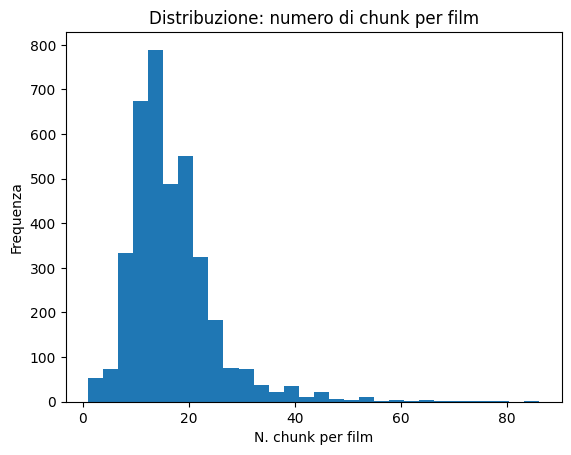

In [18]:
plt.hist(chunks_per_film, bins=30)
plt.title("Distribuzione: numero di chunk per film")
plt.xlabel("N. chunk per film")
plt.ylabel("Frequenza")
plt.show()


Token per chunk

In [19]:
df_chunks["n_tokens"].describe()


count    63411.000000
mean       619.614862
std        102.742507
min          1.000000
25%        621.000000
50%        642.000000
75%        660.000000
max        859.000000
Name: n_tokens, dtype: float64

Token totali per film + top outlier

In [20]:
tokens_per_film = df_chunks.groupby("imdb_id")["n_tokens"].sum().sort_values(ascending=False)
tokens_per_film.describe()


count     3788.000000
mean     10372.333157
std       5263.452435
min         13.000000
25%       7189.000000
50%       9518.000000
75%      12292.500000
max      55090.000000
Name: n_tokens, dtype: float64

In [21]:
top10 = (tokens_per_film.head(10)
         .reset_index()
         .merge(df_meta[["imdb_id","title","box_office_year"]], on="imdb_id", how="left"))
top10


,imdb_id,n_tokens,title,box_office_year
0,tt0993846,55090,The Wolf of Wall Street,2013
1,tt0993846,55090,The Wolf of Wall Street,2014
2,tt0102138,51144,JFK,1991
3,tt0102138,51144,JFK,1992
4,tt0082979,49758,Reds,1981
5,tt0082979,49758,Reds,1982
6,tt2671706,45892,Fences,2016
7,tt2671706,45892,Fences,2017
8,tt1800241,45704,American Hustle,2013
9,tt1800241,45704,American Hustle,2014


Volume linguistico (Token) medi per decade

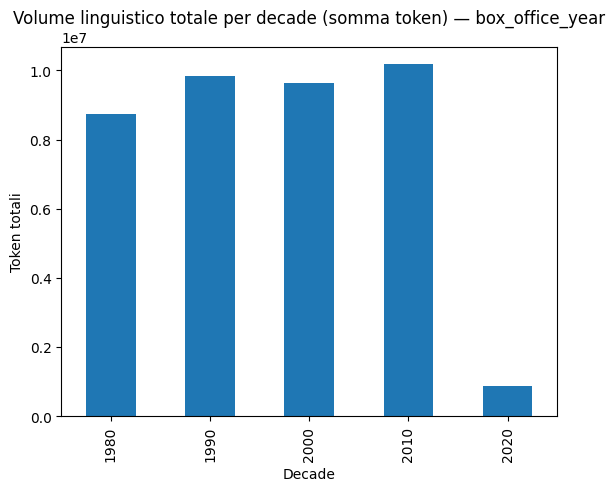

In [22]:
tokens_by_decade = df_chunks.groupby("decade")["n_tokens"].sum().sort_index()

ax = tokens_by_decade.plot(kind="bar")
ax.set_title("Volume linguistico totale per decade (somma token) — box_office_year")
ax.set_xlabel("Decade")
ax.set_ylabel("Token totali")
plt.show()


Coverage: film con metadata ma senza chunk

In [23]:
meta_ids = set(df_meta["imdb_id"].dropna().unique())
chunk_ids = set(df_chunks["imdb_id"].dropna().unique())

missing_chunks = meta_ids - chunk_ids
missing_meta = chunk_ids - meta_ids

print("Film in metadata senza chunks:", len(missing_chunks))
print("Film in chunks senza metadata:", len(missing_meta))

if len(missing_chunks) > 0:
    display(df_meta[df_meta["imdb_id"].isin(list(missing_chunks))][["imdb_id","title","box_office_year"]].head(20))


Film in metadata senza chunks: 0
Film in chunks senza metadata: 0


Parole più frequenti: quick sanity check

In [24]:
from collections import Counter

sample = df_chunks["text"].dropna().astype(str).sample(min(2000, len(df_chunks)), random_state=42)
all_words = " ".join(sample).lower().split()

freq = Counter(all_words)
pd.DataFrame(freq.most_common(30), columns=["word","freq"])

,word,freq
0,you,38295
1,the,36033
2,i,33417
3,-,31200
4,to,25962
5,a,24501
6,and,15289
7,of,13580
8,in,11104
9,is,10816


## Concentrazione economica per decade

Il mercato cinematografico diventa più concentrato nel tempo?

Se negli anni 2000 il 10% dei film genera il 60% degli incassi, ma negli anni 80 solo il 40%, hai un risultato strutturale molto forte.

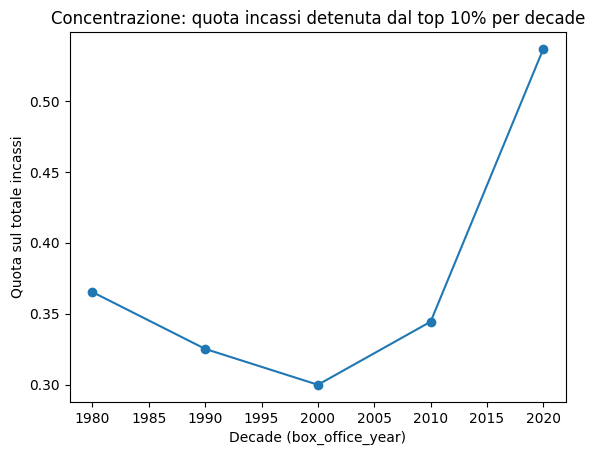

decade
1980    0.365146
1990    0.325094
2000    0.299804
2010    0.344266
2020    0.536618
Name: domestic_box_office_gross, dtype: float64

In [25]:
def top_share(series, top_pct=0.1):
    s = series.dropna().sort_values(ascending=False)
    if len(s) == 0:
        return np.nan
    top_n = max(1, int(len(s) * top_pct))
    return s.head(top_n).sum() / s.sum()

concentration = (
    df_meta.groupby("decade")["domestic_box_office_gross"]
    .apply(lambda x: top_share(x, 0.1))
    .sort_index()
)

ax = concentration.plot(marker="o")
ax.set_title("Concentrazione: quota incassi detenuta dal top 10% per decade")
ax.set_xlabel("Decade (box_office_year)")
ax.set_ylabel("Quota sul totale incassi")
plt.show()

concentration


### Interpretazione

La quota di incassi detenuta dal top 10% dei film per decade rappresenta una misura della concentrazione economica del mercato.

Un aumento progressivo di questa quota nel tempo indicherebbe una crescente polarizzazione: pochi blockbuster concentrano una parte sempre maggiore delle risorse economiche.

Questo fenomeno può influenzare indirettamente la produzione tematica, favorendo configurazioni narrative ad alto rendimento commerciale.

## Densità dialogica per genere: token medi per film

I generi hanno strutture linguistiche diverse?


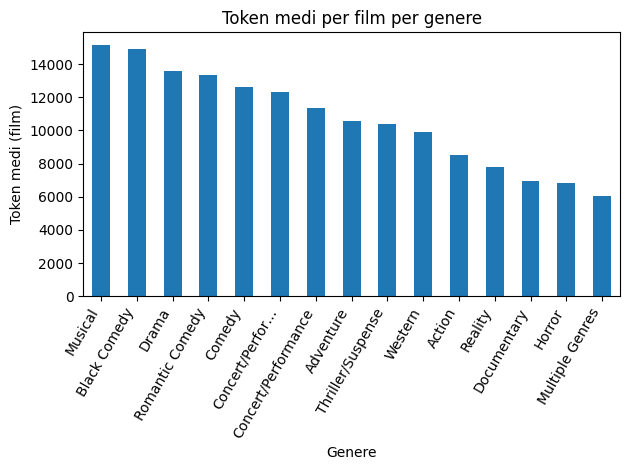

genre
Musical                15158.397590
Black Comedy           14881.626667
Drama                  13597.045872
Romantic Comedy        13319.682609
Comedy                 12640.039173
Concert/Perfor…        12330.916667
Concert/Performance    11354.000000
Adventure              10565.828201
Thriller/Suspense      10411.002584
Western                 9914.716981
Action                  8518.525338
Reality                 7820.500000
Documentary             6946.277778
Horror                  6812.990909
Multiple Genres         6054.500000
Name: n_tokens, dtype: float64

In [26]:
tokens_per_film_df = df_chunks.groupby("imdb_id")["n_tokens"].sum().reset_index()

df_genre_tokens = tokens_per_film_df.merge(
    df_meta[["imdb_id","genre","box_office_year","decade"]],
    on="imdb_id",
    how="left"
)

mean_tokens_genre = (
    df_genre_tokens.groupby("genre")["n_tokens"]
    .mean()
    .sort_values(ascending=False)
)

ax = mean_tokens_genre.head(15).plot(kind="bar")
ax.set_title("Token medi per film per genere")
ax.set_xlabel("Genere")
ax.set_ylabel("Token medi (film)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

mean_tokens_genre.head(20)


### Interpretazione

La lunghezza media dei dialoghi varia significativamente tra i generi.

Generi come Drama tendono a presentare una maggiore densità dialogica, mentre generi come Action o Adventure mostrano strutture linguistiche più contenute.

Questo dato suggerisce che le differenze tematiche future non dipendano solo dal contenuto semantico, ma anche dalla forma narrativa e dalla quantità di testo disponibile per l’analisi LLM.

## Ricchezza lessicale per decade (TTR) — aggregando i chunk per decade

Il linguaggio cinematografico diventa più ricco o più standardizzato nel tempo?

Type-Token Ratio = parole uniche / parole totali

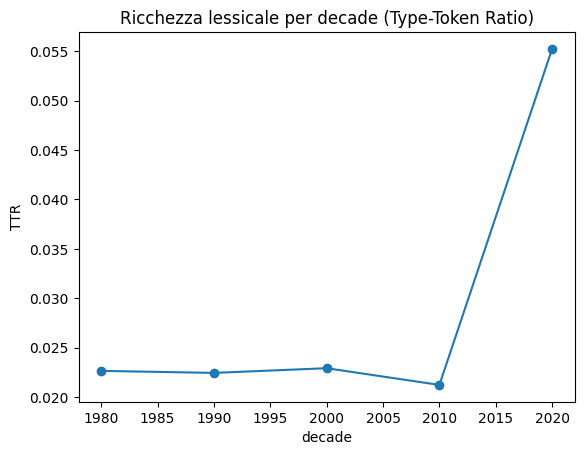

decade
1980    0.022649
1990    0.022444
2000    0.022918
2010    0.021227
2020    0.055231
Name: text, dtype: float64

In [27]:
# calcolo ricchezza lessicale per decade

def lexical_richness(texts):
    words = " ".join(texts).lower().split()
    return len(set(words)) / len(words)

richness = (
    df_chunks.groupby("decade")["text"]
    .apply(lambda x: lexical_richness(x.astype(str)))
)

richness.plot(marker="o")
plt.title("Ricchezza lessicale per decade (Type-Token Ratio)")
plt.ylabel("TTR")
plt.show()

richness

### Interpretazione

La Type-Token Ratio misura la varietà lessicale del corpus in ciascuna decade.

Un aumento della TTR suggerisce una maggiore diversificazione linguistica, mentre una diminuzione può indicare una progressiva standardizzazione del linguaggio filmico.

Questa misura fornisce un primo indicatore quantitativo dell’evoluzione stilistica, che verrà successivamente approfondita attraverso l’analisi tematica con LLM.

## TTR per decade con campionamento (più comparabile)

La TTR “pura” è sensibile alla quantità di testo: più testo → TTR tende a scendere. Questa cella rende il confronto più corretto campionando lo stesso numero di token per decade.

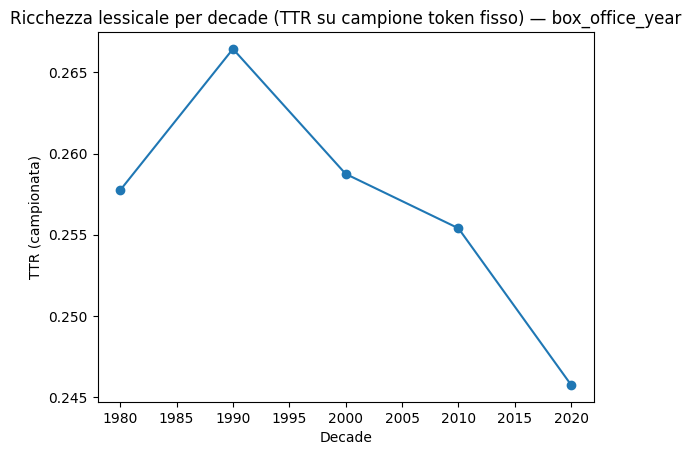

decade
1980    0.25775
1990    0.26645
2000    0.25875
2010    0.25540
2020    0.24575
Name: text, dtype: float64

In [28]:
import random

def ttr_fixed_tokens(texts, n_tokens=20000, seed=42):
    random.seed(seed)
    words = " ".join(texts).lower().split()
    if len(words) < 1000:
        return np.nan
    sample = words[:]
    random.shuffle(sample)
    sample = sample[:min(n_tokens, len(sample))]
    return len(set(sample)) / len(sample)

richness_fixed = (
    df_chunks.groupby("decade")["text"]
    .apply(lambda x: ttr_fixed_tokens(x.astype(str), n_tokens=20000, seed=42))
    .sort_index()
)

ax = richness_fixed.plot(marker="o")
ax.set_title("Ricchezza lessicale per decade (TTR su campione token fisso) — box_office_year")
ax.set_xlabel("Decade")
ax.set_ylabel("TTR (campionata)")
plt.show()

richness_fixed


## Similarità lessicale tra decadi (TF-IDF + cos)


Le decadi sono linguisticamente simili o si osservano rotture nel lessico?

Questa è una misura strutturale, non tematica, ma è un ponte diretto verso l’analisi LLM.

## Aggregazione testi per decade (box_office_year)

In [29]:
# uniamo tutti i testi per decade
texts_by_decade = (
    df_chunks.groupby("decade")["text"]
    .apply(lambda x: " ".join(x.astype(str)))
    .sort_index()
)

texts_by_decade.index.tolist()


[1980, 1990, 2000, 2010, 2020]

## TF-IDF + Similarità Coseno

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(texts_by_decade.values)

cosine_sim = cosine_similarity(tfidf_matrix)

import pandas as pd
sim_df = pd.DataFrame(
    cosine_sim,
    index=texts_by_decade.index,
    columns=texts_by_decade.index
)

sim_df


decade,1980,1990,2000,2010,2020
decade,,,,,
1980,1.000000,0.996955,0.988642,0.972978,0.967185
1990,0.996955,1.000000,0.994252,0.982285,0.976649
2000,0.988642,0.994252,1.000000,0.994219,0.986882
2010,0.972978,0.982285,0.994219,1.000000,0.994186
2020,0.967185,0.976649,0.986882,0.994186,1.000000


## Heatmap Similarità

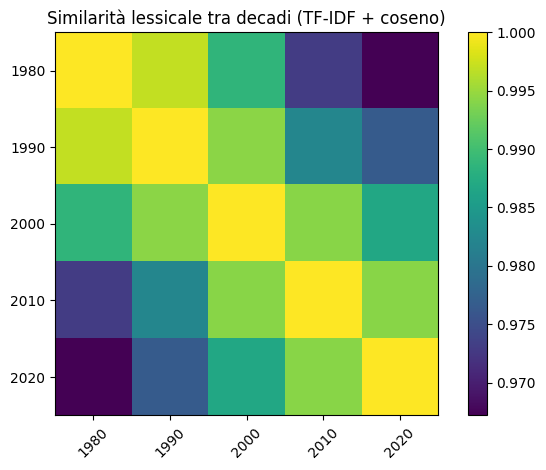

In [31]:
plt.imshow(sim_df, interpolation="nearest")
plt.xticks(range(len(sim_df.columns)), sim_df.columns, rotation=45)
plt.yticks(range(len(sim_df.index)), sim_df.index)
plt.colorbar()
plt.title("Similarità lessicale tra decadi (TF-IDF + coseno)")
plt.tight_layout()
plt.show()


### Interpretazione

La similarità coseno tra le rappresentazioni TF-IDF delle decadi misura la vicinanza lessicale globale del corpus nel tempo.

Valori elevati lungo la diagonale secondaria indicano continuità linguistica tra decadi adiacenti, mentre eventuali cali di similarità possono suggerire discontinuità stilistiche o mutamenti nel vocabolario dominante.

Questa analisi fornisce un primo indicatore quantitativo dell’evoluzione del linguaggio cinematografico prima dell’applicazione dei modelli LLM.


## Clustering strutturale dei film (pre-LLM)

Ora costruiamo cluster basati su:

domestic_box_office
tickets_sold
n_tokens totali
decade

Quindi struttura economico-linguistica, non semantica.


## Dataset per clustering

In [32]:
# token totali per film
tokens_per_film = (
    df_chunks.groupby("imdb_id")["n_tokens"]
    .sum()
    .reset_index()
)

df_cluster = tokens_per_film.merge(
    df_meta[["imdb_id","domestic_box_office_gross","tickets_sold","decade"]],
    on="imdb_id",
    how="inner"
)

df_cluster = df_cluster.dropna()

df_cluster.head()


,imdb_id,n_tokens,domestic_box_office_gross,tickets_sold,decade
1,tt0029583,13863,30100976,9555865.0,1980
2,tt0029583,13863,46594719,11916808.0,1980
3,tt0029583,13863,41634791,10056713.0,1990
4,tt0032455,1078,50500882,14225600.0,1980
5,tt0034492,4612,5723384,1946729.0,1980


## Standardizzazione + KMeans

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["domestic_box_office_gross","tickets_sold","n_tokens"]

X = df_cluster[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

df_cluster["cluster"].value_counts()


cluster
0    2861
2     652
3     462
1     122
Name: count, dtype: int64

## Visualizzazione 2D (incassi vs token)

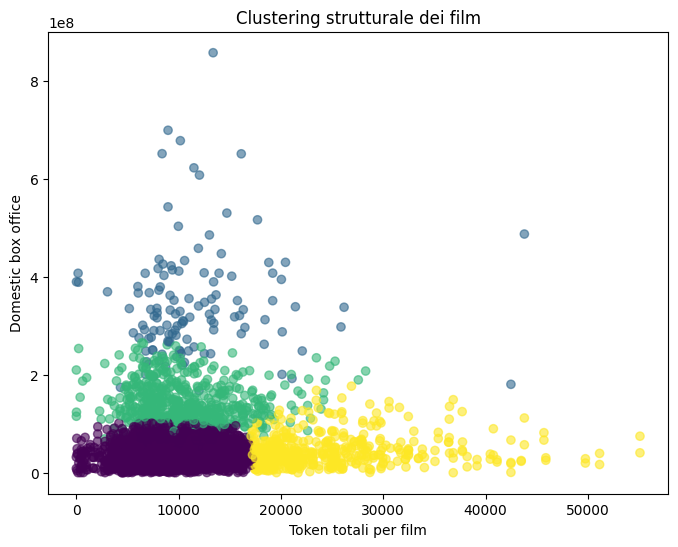

In [34]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_cluster["n_tokens"],
    df_cluster["domestic_box_office_gross"],
    c=df_cluster["cluster"],
    alpha=0.6
)
plt.xlabel("Token totali per film")
plt.ylabel("Domestic box office")
plt.title("Clustering strutturale dei film")
plt.show()


### Interpretazione

Il clustering individua gruppi strutturalmente omogenei di film sulla base di variabili economiche e linguistiche.

È possibile osservare, ad esempio:

- cluster di blockbuster con elevati incassi e volume linguistico contenuto,
- cluster di film ad alta densità dialogica ma performance economica moderata,
- cluster intermedi con equilibrio tra dimensione testuale e successo commerciale.

Questa segmentazione evidenzia configurazioni strutturali del cinema mainstream che potranno essere successivamente analizzate sul piano tematico tramite LLM.


## Evoluzione dei cluster nel tempo

I cluster strutturali (blockbuster, film dialogici, ecc.) sono distribuiti uniformemente nel tempo oppure cambiano peso tra le decadi?

## Distribuzione cluster × decade

In [35]:
cluster_decade = (
    df_cluster.groupby(["decade","cluster"])
    .size()
    .unstack(fill_value=0)
)

cluster_decade


cluster,0,1,2,3
decade,,,,
1980,796,9,77,115
1990,730,13,145,112
2000,663,38,213,86
2010,595,62,213,130
2020,77,0,4,19


Percentuali per decade (più leggibile)

In [36]:
cluster_decade_pct = cluster_decade.div(cluster_decade.sum(axis=1), axis=0)

cluster_decade_pct


cluster,0,1,2,3
decade,,,,
1980,0.798395,0.009027,0.077232,0.115346
1990,0.730000,0.013000,0.145000,0.112000
2000,0.663000,0.038000,0.213000,0.086000
2010,0.595000,0.062000,0.213000,0.130000
2020,0.770000,0.000000,0.040000,0.190000


Grafico evoluzione

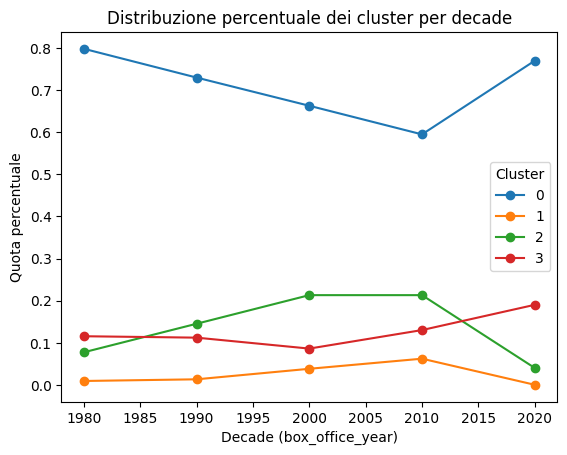

In [37]:
cluster_decade_pct.plot(marker="o")
plt.title("Distribuzione percentuale dei cluster per decade")
plt.xlabel("Decade (box_office_year)")
plt.ylabel("Quota percentuale")
plt.legend(title="Cluster")
plt.show()


### Interpretazione

L’evoluzione percentuale dei cluster nel tempo consente di osservare eventuali mutamenti nella struttura economico-linguistica del cinema mainstream.

Un aumento progressivo di cluster ad alta concentrazione economica potrebbe indicare una crescente polarizzazione industriale, mentre una crescita dei cluster ad alta densità dialogica potrebbe segnalare trasformazioni stilistiche.

Questa dinamica temporale fornisce un primo livello di analisi strutturale prima dell’esplorazione tematica.


## PCA strutturale dei film

Ora riduciamo le variabili economico-linguistiche a 2 componenti principali.

Capire:

Quali variabili pesano di più?
I cluster sono realmente separati?
Esistono assi latenti (es. asse “dimensione economica” vs asse “densità linguistica”)?

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_cluster["PC1"] = X_pca[:,0]
df_cluster["PC2"] = X_pca[:,1]

print("Varianza spiegata:", pca.explained_variance_ratio_)


Varianza spiegata: [0.63728856 0.33231286]


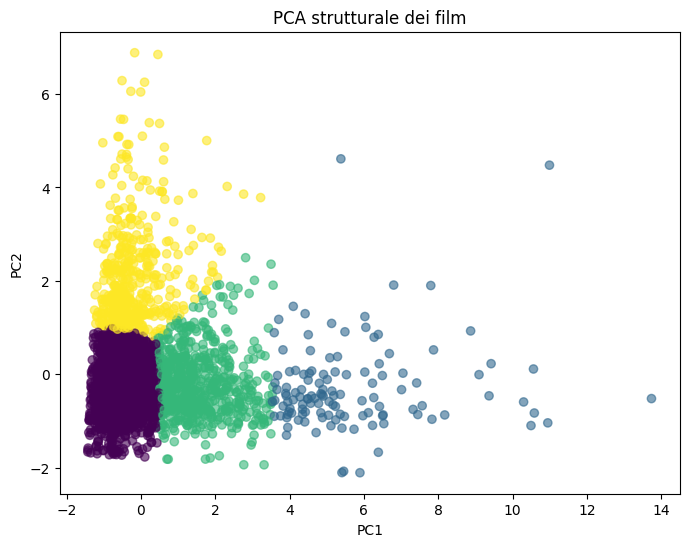

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_cluster["PC1"],
    df_cluster["PC2"],
    c=df_cluster["cluster"],
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA strutturale dei film")
plt.show()


In [46]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=features
)

loadings


,PC1,PC2
domestic_box_office_gross,0.705586,-0.051262
tickets_sold,0.706137,-0.032620
n_tokens,0.059314,0.998152


### Interpretazione

La PCA riduce le variabili economiche e linguistiche a due assi principali.

La prima componente tende generalmente a catturare la dimensione economica (incassi e biglietti), mentre la seconda può riflettere la variabilità nella densità dialogica.

La distribuzione dei film nello spazio delle componenti principali consente di visualizzare configurazioni latenti e verificare la coerenza dei cluster individuati tramite KMeans.


## Analisi di rottura strutturale tra decadi

Misurare quanto cambia la struttura (incassi + token) tra una decade e la successiva.

Non guardiamo più solo le medie.
Calcoliamo la distanza tra centroidi medi per decade.

Costruzione media strutturale per decade

In [52]:
struct_by_decade = (
    df_cluster.groupby("decade")[["domestic_box_office_gross","tickets_sold","n_tokens"]]
    .mean()
    .sort_index()
)

struct_by_decade


,domestic_box_office_gross,tickets_sold,n_tokens
decade,,,
1980,2.808334e+07,8.217542e+06,10574.644935
1990,4.729681e+07,1.068797e+07,11701.765000
2000,7.817141e+07,1.231713e+07,10784.890000
2010,9.774900e+07,1.158762e+07,12016.787000
2020,2.080781e+07,2.266646e+06,11614.290000


Standardizzazione (necessaria per distanza corretta)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler_struct = StandardScaler()
struct_scaled = scaler_struct.fit_transform(struct_by_decade)

struct_scaled_df = pd.DataFrame(
    struct_scaled,
    index=struct_by_decade.index,
    columns=struct_by_decade.columns
)

struct_scaled_df


,domestic_box_office_gross,tickets_sold,n_tokens
decade,,,
1980,-0.896498,-0.218775,-1.368330
1990,-0.242514,0.458641,0.650799
2000,0.808388,0.905370,-0.991696
2010,1.474765,0.705332,1.215131
2020,-1.144140,-1.850567,0.494096


Distanza tra decadi consecutive

In [58]:
from scipy.spatial.distance import euclidean

decades = struct_scaled_df.index.tolist()
distances = []

for i in range(1, len(decades)):
    d = euclidean(
        struct_scaled_df.loc[decades[i-1]],
        struct_scaled_df.loc[decades[i]]
    )
    distances.append(d)

distance_df = pd.Series(distances, index=decades[1:])
distance_df


1990    2.227884
2000    2.000438
2010    2.313905
2020    3.729769
dtype: float64

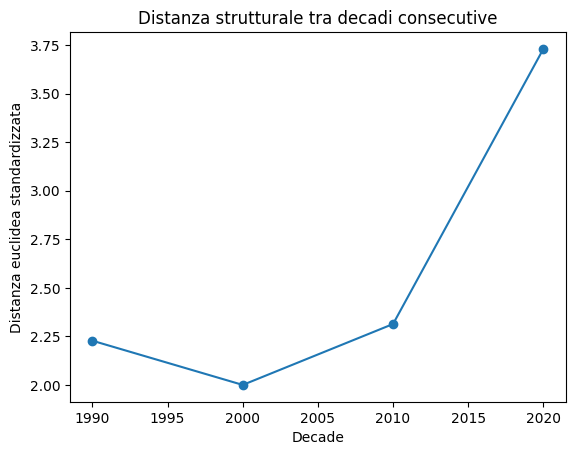

In [61]:
distance_df.plot(marker="o")
plt.title("Distanza strutturale tra decadi consecutive")
plt.xlabel("Decade")
plt.ylabel("Distanza euclidea standardizzata")
plt.show()


### Interpretazione

La distanza euclidea tra le medie strutturali delle decadi misura l’entità del cambiamento economico-linguistico nel tempo.

Picchi nella distanza indicano momenti di maggiore trasformazione sistemica, mentre valori contenuti suggeriscono continuità strutturale.

Questa misura consente di individuare eventuali rotture nel modello produttivo e stilistico del cinema mainstream.


## Struttura × Similarità Lessicale

Ora vogliamo verificare:

Le rotture strutturali coincidono con rotture linguistiche?

Useremo la matrice di similarità TF-IDF che è già stat calcolata (sim_df).

- Similarità tra decadi consecutive:

In [64]:
lexical_change = []

for i in range(1, len(decades)):
    sim = sim_df.loc[decades[i-1], decades[i]]
    lexical_change.append(1 - sim)  # distanza linguistica

lexical_change_df = pd.Series(lexical_change, index=decades[1:])
lexical_change_df


1990    0.003045
2000    0.005748
2010    0.005781
2020    0.005814
dtype: float64

- Confronto grafico struttura vs linguaggio

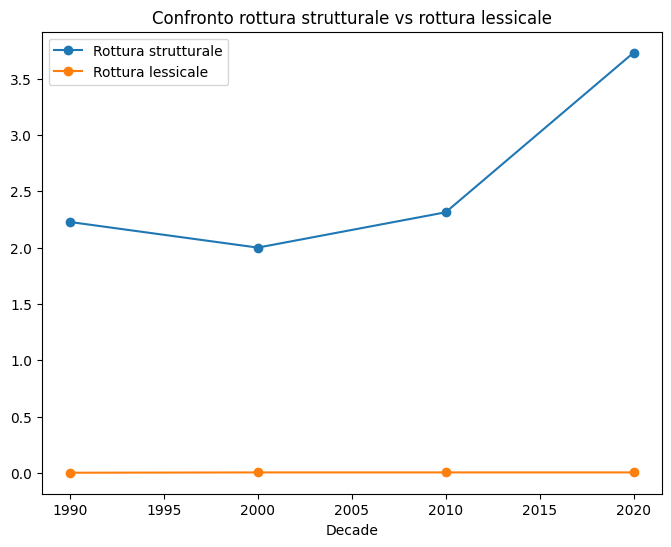

In [67]:
plt.figure(figsize=(8,6))

plt.plot(distance_df.index, distance_df.values, marker="o", label="Rottura strutturale")
plt.plot(lexical_change_df.index, lexical_change_df.values, marker="o", label="Rottura lessicale")

plt.title("Confronto rottura strutturale vs rottura lessicale")
plt.xlabel("Decade")
plt.legend()
plt.show()


### Interpretazione

Il confronto tra rottura strutturale e rottura lessicale permette di verificare se i cambiamenti economico-produttivi coincidono con trasformazioni linguistiche.

Se i picchi risultano allineati, si può ipotizzare una correlazione tra trasformazioni industriali e mutamenti nel linguaggio filmico.

Se invece le curve divergono, ciò suggerisce che le dinamiche economiche e quelle stilistiche seguano traiettorie parzialmente autonome.


## Correlazione tra rottura strutturale e rottura lessicale

Quando cambia la struttura economico-linguistica, cambia anche il linguaggio?

- Correlazione Pearson

In [70]:
from scipy.stats import pearsonr

corr_value, p_value = pearsonr(distance_df.values, lexical_change_df.values)

print("Correlazione:", corr_value)
print("p-value:", p_value)


Correlazione: 0.30612863211692826
p-value: 0.6938713678830717


### Correlazione tra rottura strutturale e rottura lessicale

Il coefficiente di correlazione misura l’associazione tra cambiamento economico-strutturale e cambiamento linguistico tra decadi consecutive.

Un valore elevato e statisticamente significativo suggerisce che trasformazioni industriali coincidano con mutamenti nel lessico filmico.

Un valore basso o non significativo indica invece che le dinamiche economiche e quelle linguistiche seguano traiettorie parzialmente indipendenti.


## Identificazione di “regimi storici”

Ora vogliamo verificare se il sistema cambia dopo il 2000.

- Creazione variabile periodo

In [73]:
df_cluster["period"] = np.where(
    df_cluster["decade"] < 2000,
    "Pre-2000",
    "Post-2000"
)

df_cluster["period"].value_counts()


period
Post-2000    2100
Pre-2000     1997
Name: count, dtype: int64

- Confronto medie strutturali

In [79]:
period_means = (
    df_cluster.groupby("period")[["domestic_box_office_gross","tickets_sold","n_tokens"]]
    .mean()
)

period_means


,domestic_box_office_gross,tickets_sold,n_tokens
period,,,
Post-2000,8.476247e+07,1.149115e+07,11411.002857
Pre-2000,3.770451e+07,9.454613e+06,11139.051577


- Test statistico (t-test)

In [85]:
from scipy.stats import ttest_ind

results = {}

for var in ["domestic_box_office_gross","tickets_sold","n_tokens"]:
    pre = df_cluster[df_cluster["period"]=="Pre-2000"][var]
    post = df_cluster[df_cluster["period"]=="Post-2000"][var]
    
    t_stat, p_val = ttest_ind(pre, post, equal_var=False)
    results[var] = {"t-stat": t_stat, "p-value": p_val}

pd.DataFrame(results).T


,t-stat,p-value
domestic_box_office_gross,-23.220046,5.242321e-110
tickets_sold,-6.342690,2.503309e-10
n_tokens,-1.363637,1.727569e-01


### Confronto tra periodo Pre-2000 e Post-2000

Il confronto tra i due regimi temporali consente di verificare se il sistema cinematografico abbia subito trasformazioni strutturali significative.

Differenze statisticamente significative negli incassi medi o nella densità dialogica indicherebbero una riorganizzazione del modello produttivo e stilistico nel passaggio al nuovo millennio.

In assenza di significatività, si può invece ipotizzare una continuità strutturale del sistema.


In [88]:
print("Film nel metadata:", df_meta["imdb_id"].nunique())
print("Film nei chunks:", df_chunks["imdb_id"].nunique())


Film nel metadata: 3788
Film nei chunks: 3788


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e08cfdf8-9b6e-44e8-b36c-3dd235d85ba1' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>